# Demo - datasets - analysing datasets for PARNET


Requires the eCLIP and globalCLIP "synchronized" datasets, i.e. the files for which we only have the windows which contain signals in both eCLIP and globalCLIP tracks. These can be downloaded from the google drive and should be saved in 'resources/global_clip' (or adapt the filepaths.yaml config).

Runs simple exploration of dataset structure and visualizes the different tracks.  

## Set up

### Imports

In [ ]:
import pylbsr.notebooks
import pylbsr.misc
from dotmap import DotMap
import gzip
import pandas as pd
import numpy as np
import torch
import yaml
import numpy as np
from functools import partial
import matplotlib.pyplot as plt

### Parameters

In [2]:
_notebook_name = "prepare_datasets.py.ipynb"
_notebook_path = f"notebooks/demo--train-spliceosome-hepg2/{_notebook_name}"
logger = pylbsr.misc.init_logger(_notebook_name)

PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)

logger.info(f"Project directory: {PROJECT_DIR}")

[11:16:38] INFO - Project directory: /Users/GravelBarbara/Documents/RBP_project/parnet--demo--train-models


### Filepaths

In [3]:
from pathlib import Path

_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.lambosaur-ms-01-2.yaml").read_text())


def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p


FILEPATHS = DotMap()

FILEPATHS["parnet_data"] = {
    "data": _res(_fp_cfg["parnet_encore_eclip"]["data_600nt_globalclipmatched_pt"]),
}

FILEPATHS["globalclip_data_control1"] = {
    "data": _res(_fp_cfg["global_clip"]["data_interphase_control"]),
}

FILEPATHS["globalclip_data_control2"] = {
    "data": _res(_fp_cfg["global_clip"]["data_lysate_control"]),
}

FILEPATHS["filtered_dataset"] = _res(_fp_cfg["results"]["filtered_dataset_spliceosome_hepg2"])
FILEPATHS["parnet_rbp_metadata"]= {"full_rbp_set": _res(_fp_cfg["metadata"]["full_rbp_set"])}

## Exploring the dataset structure

In [4]:
## Load the parnet_data and one globalClip data
## This will take a bit of time
logger.info("Loading full 600 nt parnet .pt.gz dataset")
with gzip.open(FILEPATHS["parnet_data"]["data"], "rb") as _f:
    parnet_data = torch.load(_f, weights_only=False)
logger.info(f"Loaded splits: {list(parnet_data.keys())}")

logger.info("Loading full 600 nt globalClip .pt.gz dataset")
with gzip.open(FILEPATHS["globalclip_data_control1"]["data"], "rb") as _f:
    globalclip_data = torch.load(_f, weights_only=False)
logger.info(f"Loaded splits: {list(globalclip_data.keys())}")

[11:16:38] INFO - Loading full 600 nt parnet .pt.gz dataset
[11:18:17] INFO - Loaded splits: ['valid', 'train', 'test', 'metadata']
[11:18:17] INFO - Loading full 600 nt globalClip .pt.gz dataset
[11:18:24] INFO - Loaded splits: ['valid', 'train', 'test', 'metadata']


The 'metadata' key is completely separate from the training items. It details global experiment settings used when compiling this particular dataset slice.

In [5]:
meta_block = parnet_data['metadata']
print("--- Global Metadata Properties ---")
for key, value in meta_block.items():
    print(f"{key}: {value}")
    
# Print out data split proportions
print("\n--- Split Size Breakdowns ---")
for split in ['train', 'valid', 'test']:
    print(f"  → Number of elements in '{split}': {len(parnet_data[split])} regions")

--- Global Metadata Properties ---
description: eCLIP (eCLIP + control, 223 tracks)
min_signal_threshold: 3.0
target_len: 600
valid_size: 7361
train_size: 39052
test_size: 4946

--- Split Size Breakdowns ---
  → Number of elements in 'train': 39052 regions
  → Number of elements in 'valid': 7361 regions
  → Number of elements in 'test': 4946 regions


Now we can look at at how each region is represented. 

In [6]:
# Grab an example entry
sample_region = parnet_data['train'][0]

print("--- Data Structure of a Single Entry in parnet_data ---")
print(f"Type of entry: {type(sample_region)}")
print(f"Keys inside entry: {list(sample_region.keys())}\n")

print("METADATA LAYER ('meta'):")
for k, v in sample_region['meta'].items():
    print(f"  {k}: {v}")

print("\n FEATURE INPUTS LAYER ('inputs'):")
seq_data = sample_region['inputs']['sequence']
print(f"Data Type: {type(seq_data)}")
print(f"Seq: {seq_data}")
print(f"Length seq_data: {len(seq_data)}")

print("\n TARGET OUTPUTS LAYER ('outputs'):")
print(f"Tasks available in this file: {list(sample_region['outputs'].keys())}")
print(f"Number of tracks available in this file: {sample_region['outputs']['eCLIP']['size'][0]}")

--- Data Structure of a Single Entry in parnet_data ---
Type of entry: <class 'dict'>
Keys inside entry: ['meta', 'inputs', 'outputs']

METADATA LAYER ('meta'):
  name: chr4:3512611-3513211:-
  pad_side: -1

 FEATURE INPUTS LAYER ('inputs'):
Data Type: <class 'str'>
Seq: TACTGAGCTGCTTTTGTGATTTGAGCATTTCTGGATGGGTGTGGAATTGGAAAGTCAGATGTGCAGGGCTTGCGCCTTTTCCTTTTGGATCGCGCGTCTCCTGACATGAGGCTGAGCTCACAGAGCTGGCCTCGAGGCGCGCTGTCCCCAGCTGATGAGACGTTTCTGTCCACAGGTGAAGAAGCATCTGCAGGACCTGTCCGGCAGGATCTCCAGAGCTCGGCACAACGAACTCTGAAGGCATTGGGGAGCCCAGCCCGGCAGGGAAGAGGCCAGCGTGAAGGACCTGGGCTCTTGGCCGTGGCATTTCCGTGGACAGCCCGCCGTCAGGGTGGCTGGGGCTGGCACGGGTGTCGAGGCAGGAAGGATTGTTTCTGGTGACTGCAGCCGCTGCCGTCGCGACACAGGGCTTGGTGGTGGTAGCATTTGGGTCTGAGATCGGCCCAGCTCTGACTGAAGGGGCTTGGCTTCCACTCAGCATCAGCGTGGCAGTCACCACCCCAGTGAGGACCTCGATGTCCAGCTGCTGTCAGGTCTGATAGTCCTCTGCTAAAACAACACGATTTACATAAAAAATCTTACACATCTGCCACCGGAAAT
Length seq_data: 600

 TARGET OUTPUTS LAYER ('outputs'):
Tasks available in this file: ['eCLIP', 'control']
Number of tracks av

In [7]:
sample_region = globalclip_data['train'][0]

print("--- Data Structure of a Single Entry in globalClip_data ---")
print(f"Type of entry: {type(sample_region)}")
print(f"Keys inside entry: {list(sample_region.keys())}\n")

print("METADATA LAYER ('meta'):")
for k, v in sample_region['meta'].items():
    print(f"  {k}: {v}")

print("\n FEATURE INPUTS LAYER ('inputs'):")
seq_data = sample_region['inputs']['sequence']
print(f"Data Type: {type(seq_data)}")
print(f"Length seq_data: {len(seq_data)}")

print("\n TARGET OUTPUTS LAYER ('outputs'):")
print(f"Tasks available in this file: {list(sample_region['outputs'].keys())}")
print(f"Number of tracks available in this file: {sample_region['outputs']['globalCLIP']['size'][0]}")

--- Data Structure of a Single Entry in globalClip_data ---
Type of entry: <class 'dict'>
Keys inside entry: ['meta', 'inputs', 'outputs']

METADATA LAYER ('meta'):
  name: chr4:3512611-3513211:-
  pad_side: -1

 FEATURE INPUTS LAYER ('inputs'):
Data Type: <class 'str'>
Length seq_data: 600

 TARGET OUTPUTS LAYER ('outputs'):
Tasks available in this file: ['globalCLIP', 'control']
Number of tracks available in this file: 1


### Visualizing and comparing signals across eCLIP tracks and globalCLIP track

To visualize the signals they need to be extracted from sparse tensor to dense and then visualized using matplotlib.

In [8]:
# Define helper functions to decompress the sparse representation back to dense matrices
def torch_sparse_to_dense(sparse_dict):
    """
    Converts ParNet sparse dictionary layout back to a standard 2D PyTorch Tensor.
    """
    dense = torch.zeros(sparse_dict['size'])
    # Assign signal values to specific 2D matrix coordinates (Track, Position)
    dense[sparse_dict['indices'][0], sparse_dict['indices'][1]] = sparse_dict['values']
    return dense

In [9]:
# Define target RBPs we are interested in analyzing
target_rbp_names = ["PRPF8", "U2AF2", "AQR"]  # Adjust names to match your dataset labels

# Convert the human-readable names to their corresponding indices in parnet_data
# (Assuming saved_meta['rbp_cts'] holds the task name strings in order)
rbps_ct_df = pd.read_csv(FILEPATHS["parnet_rbp_metadata"]["full_rbp_set"], sep="\t")['rbp_ct']

# Find indices for your specific target RBPs
rbp_signal_task_indices = []
for name in target_rbp_names:
    # Match strings containing your RBP name (e.g., "RBFOX2_HepG2")
    matched_idx = [i for i, label in enumerate(rbps_ct_df) if name in label]
    if matched_idx:
        rbp_signal_task_indices.append(matched_idx[0])

In [10]:
# ── FIND THE REGION WITH THE STRONGEST COMBINED TARGET SIGNAL ─────────
print("Scanning dataset regions to find the highest total eCLIP read volume...")
region_scores = []

# Loop over the test split (since it is smaller)
active_split_parnet = parnet_data['test']
active_split_gclip = globalclip_data['test']

for i, item in enumerate(active_split_parnet):
    per_track_sums = []
    # Assess signal using the sum over the entire region width for our chosen tasks
    for task_idx in rbp_signal_task_indices:
        # Task name keys inside item['outputs'] typically match the rbp_labels_list names
        #task_name = rbps_ct_df.iloc([task_idx])['rbp_ct']
        #if task_name in item['outputs']:
        dense_signal = torch_sparse_to_dense(item['outputs']['eCLIP'])[task_idx]
        track_sum = float(dense_signal.float().numpy().sum())
        per_track_sums.append(track_sum)
    ## Also add the gclip signal
    item_gclip = active_split_gclip[i]
    dense_signal = torch_sparse_to_dense(item_gclip['outputs']['globalCLIP'])[0]
    track_sum = float(dense_signal.float().numpy().sum())
    per_track_sums.append(track_sum)
    
    score = np.min(per_track_sums)
    region_scores.append(score)

best_region_idx = int(np.argmax(region_scores))
best_score = region_scores[best_region_idx]
# Find the best region index based on total area signal sum
best_region_idx = int(np.argmax(region_scores))
print(f"Region Located: Region index #{best_region_idx} has a minimum of {best_score} total reads across your target RBPs.")

Scanning dataset regions to find the highest total eCLIP read volume...
Region Located: Region index #1154 has a minimum of 668.0 total reads across your target RBPs.


In [11]:
region_coordinate_name = parnet_data['test'][best_region_idx]['meta']['name']

# Extract data arrays
plotting_tracks = []

# Add the 3 regular eCLIP tracks from parnet_data
for i, task_idx in enumerate(rbp_signal_task_indices):
    rbp_name = target_rbp_names[i]
    signal = torch_sparse_to_dense(active_split_parnet[best_region_idx]['outputs']['eCLIP'])[task_idx]
    signal_control = torch_sparse_to_dense(active_split_parnet[best_region_idx]['outputs']['control'])[task_idx]
    plotting_tracks.append((f"eCLIP: {rbp_name}", signal.float().numpy(), "steelblue"))
    plotting_tracks.append((f"eCLIP: {rbp_name} control", signal_control.float().numpy(), "gray"))


# Add your 1 new globalCLIP track from global_clip_data
gclip_signal = torch_sparse_to_dense(active_split_gclip[best_region_idx]['outputs']['globalCLIP'])[0]
plotting_tracks.append(("globalCLIP", gclip_signal.float().numpy(), "darkorange"))

gclip_control = torch_sparse_to_dense(active_split_gclip[best_region_idx]['outputs']['control'])[0]
plotting_tracks.append(("Control", gclip_control.float().numpy(), "green"))



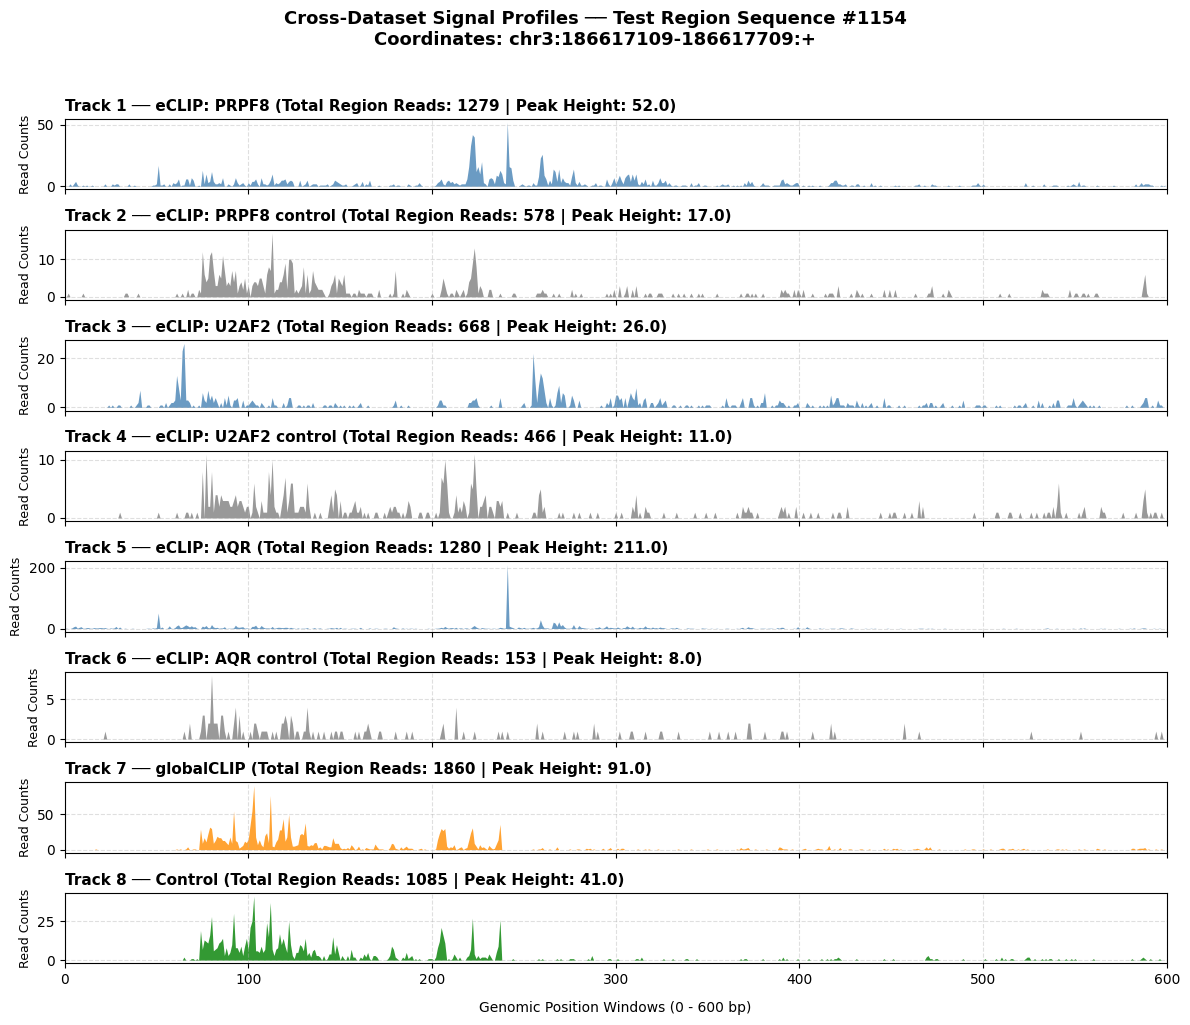

In [12]:
pos_axis = np.arange(600)
fig, axes = plt.subplots(8, 1, figsize=(12, 10), sharex=True)

for idx, (label, signal_array, color) in enumerate(plotting_tracks):
    ax = axes[idx]
    
    # Fill under curve for clean peak tracking visualization
    ax.fill_between(pos_axis, signal_array, alpha=0.8, color=color, linewidth=0)
    
    track_sum = int(np.sum(signal_array))
    track_max = np.max(signal_array)
    
    # Label each separate plot layout cleanly
    ax.set_title(f"Track {idx+1} ── {label} (Total Region Reads: {track_sum} | Peak Height: {track_max:.1f})", 
                 fontweight='bold', fontsize=11, loc='left')
    ax.set_ylabel("Read Counts", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim(0, 600)

plt.xlabel("Genomic Position Windows (0 - 600 bp)", fontsize=10, labelpad=10)
plt.suptitle(f"Cross-Dataset Signal Profiles ── Test Region Sequence #{best_region_idx}\nCoordinates: {region_coordinate_name}", 
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()